In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv(
    "../data/employees_final.csv",
    keep_default_na=False,
    na_values=[""]
)

In [3]:
# Shape of dataset
print("Shape:", df.shape)

# First five rows
df.head()

Shape: (9992, 25)


,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,application_date,last_contact_date,last_contact_channel,plan_tier_requested,broker_channel,prior_year_enrolled,legacy_propensity_score,n_employees_region,hist_enrollment_rate_region,avg_salary_region,avg_premium_cost_usd,benefits_broker_rating,hr_outreach_capacity,open_enrollment_window_days,state_mandate_level
0,12324,28,Male,Divorced,44047.60,Full-time,West,No,1.4,0,2024-04-14,2024-03-30,SMS,Basic,Employer-Sponsored,No,0.104,2582,0.613,65007.07,574,4.7,437,28,Low
1,17825,23,Male,Married,80111.28,Full-time,Midwest,Yes,0.5,1,2024-05-09,2024-04-18,Phone,Standard,Direct,New Hire,0.874,2488,0.617,64921.46,595,4.4,469,18,High
2,15200,39,Male,Married,69855.65,Full-time,South,Yes,3.4,1,2024-06-22,2024-06-09,None,Silver,Direct,No,0.870,2424,0.628,65200.49,481,3.3,324,17,Medium
3,16690,31,Female,Married,91567.33,Full-time,South,No,1.2,1,2024-08-16,2024-07-29,Email,Premium,Employer-Sponsored,Yes,0.894,2424,0.628,65200.49,481,3.3,324,17,Medium
4,17465,42,Female,Single,59861.68,Contract,Midwest,Yes,23.8,0,2024-05-13,2024-05-06,Email,Standard,Employer-Sponsored,New Hire,0.163,2488,0.617,64921.46,595,4.4,469,18,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9992 entries, 0 to 9991
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  9992 non-null   int64  
 1   age                          9992 non-null   int64  
 2   gender                       9992 non-null   object 
 3   marital_status               9992 non-null   object 
 4   salary                       9992 non-null   float64
 5   employment_type              9992 non-null   object 
 6   region                       9992 non-null   object 
 7   has_dependents               9992 non-null   object 
 8   tenure_years                 9992 non-null   float64
 9   enrolled                     9992 non-null   int64  
 10  application_date             9273 non-null   object 
 11  last_contact_date            9992 non-null   object 
 12  last_contact_channel         9992 non-null   object 
 13  plan_tier_requeste

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,9992.0,15001.244195,2887.041253,10001.000,12500.750,15002.500,17501.2500,20000.000
age,9992.0,43.000801,12.286980,22.000,33.000,43.000,54.0000,64.000
salary,9992.0,65031.299228,14926.410590,2207.790,54711.940,65052.010,75053.6875,120312.000
tenure_years,9992.0,3.968995,3.896601,0.000,1.200,2.800,5.6000,36.000
enrolled,9992.0,0.617294,0.486072,0.000,0.000,1.000,1.0000,1.000
legacy_propensity_score,9093.0,0.605086,0.363137,0.010,0.191,0.814,0.9070,0.990
n_employees_region,9992.0,2501.250200,56.378497,2424.000,2488.000,2506.000,2582.0000,2582.000
hist_enrollment_rate_region,9992.0,0.617381,0.006291,0.612,0.612,0.613,0.6170,0.628
avg_salary_region,9992.0,65032.950260,101.117905,64921.460,65007.070,65007.070,65008.3200,65200.490
avg_premium_cost_usd,9992.0,526.864892,59.444615,455.000,455.000,574.000,574.0000,595.000


In [6]:
df.describe(include="object").T

,count,unique,top,freq
gender,9992,3,Male,4810
marital_status,9992,4,Married,4583
employment_type,9992,3,Full-time,7036
region,9992,4,West,2578
has_dependents,9992,2,Yes,5987
application_date,9273,365,2024-04-08,44
last_contact_date,9992,390,2024-10-19,43
last_contact_channel,9992,5,Email,4499
plan_tier_requested,9992,7,Standard,3919
broker_channel,9992,4,Direct,3533


In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
legacy_propensity_score,899,8.997198
application_date,719,7.195757


In [8]:
df["application_date"] = pd.to_datetime(df["application_date"])
df["last_contact_date"] = pd.to_datetime(df["last_contact_date"])

In [9]:
df["last_contact_channel"].value_counts(dropna=False)

last_contact_channel
Email      4499
Phone      2428
SMS        1478
Unknown    1181
None        406
Name: count, dtype: int64

---------------VISUALIZATION-----------------

In [10]:
df["enrolled"].value_counts()

enrolled
1    6168
0    3824
Name: count, dtype: int64

In [11]:
(df["enrolled"].value_counts(normalize=True) * 100).round(2)

enrolled
1    61.73
0    38.27
Name: proportion, dtype: float64

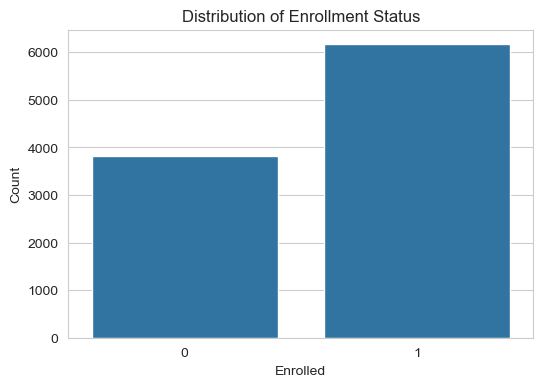

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="enrolled")

plt.title("Distribution of Enrollment Status")
plt.xlabel("Enrolled")
plt.ylabel("Count")

plt.show()

In [13]:
numerical_cols = [
    "age",
    "salary",
    "tenure_years",
    "legacy_propensity_score",
    "hist_enrollment_rate_region",
    "avg_salary_region",
    "avg_premium_cost_usd",
    "benefits_broker_rating",
    "hr_outreach_capacity",
    "open_enrollment_window_days"
]

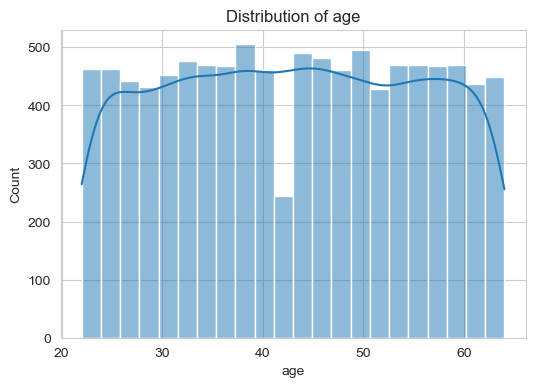

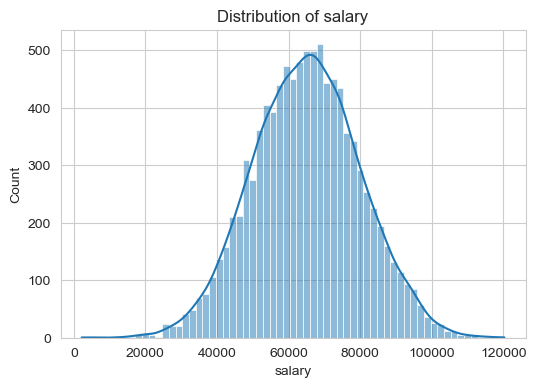

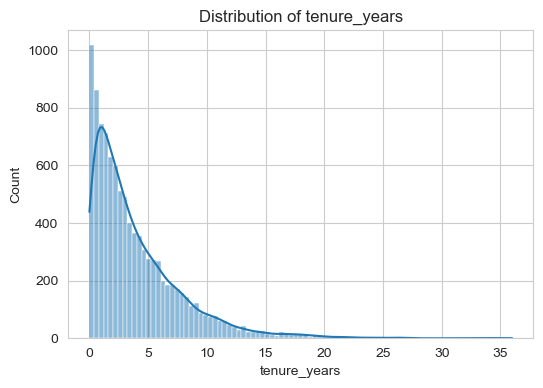

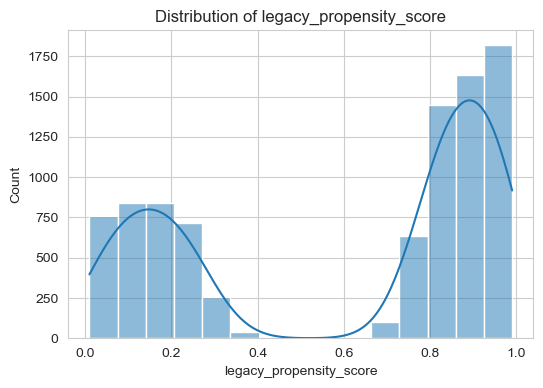

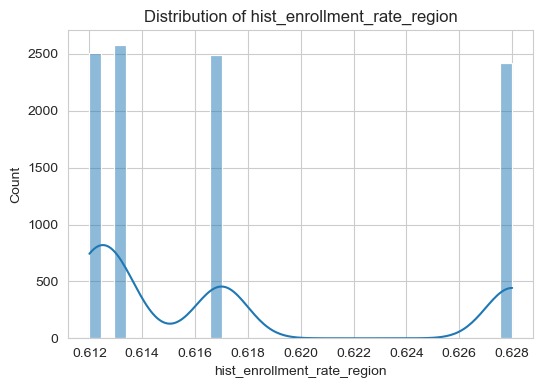

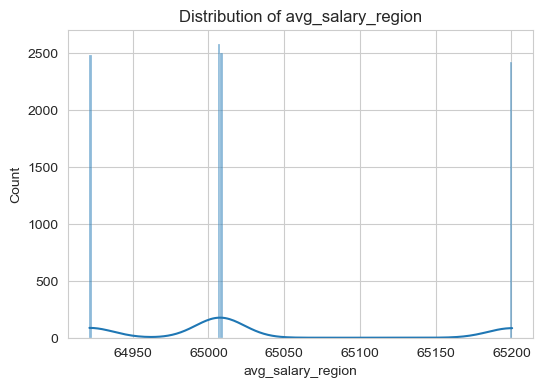

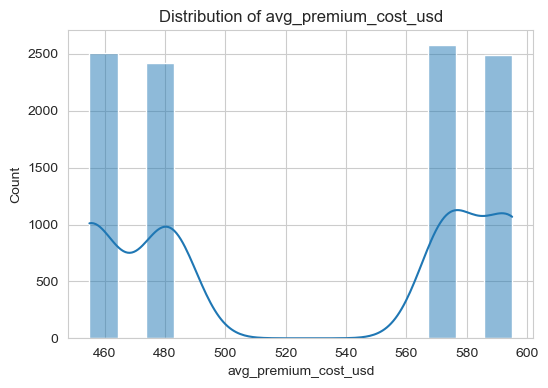

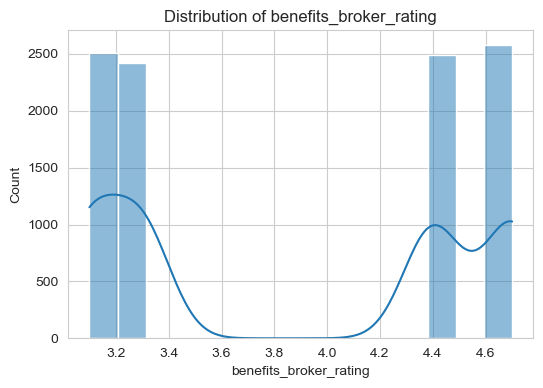

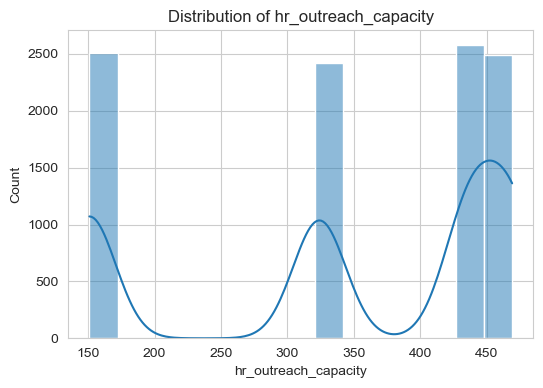

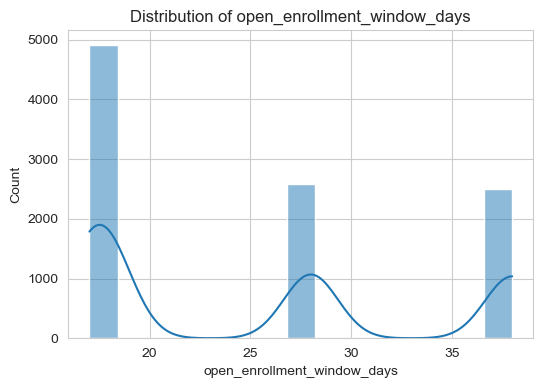

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

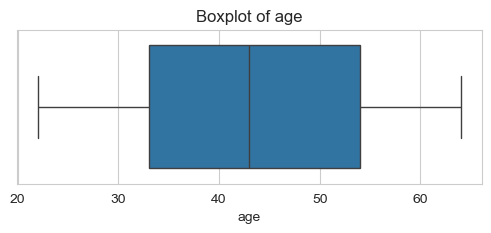

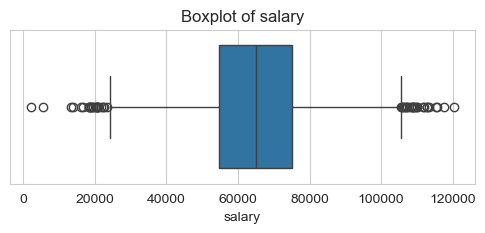

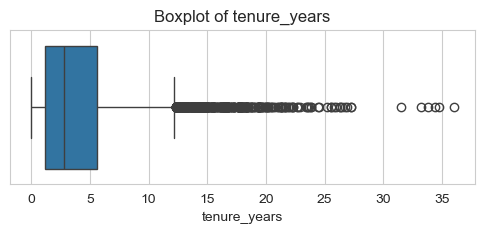

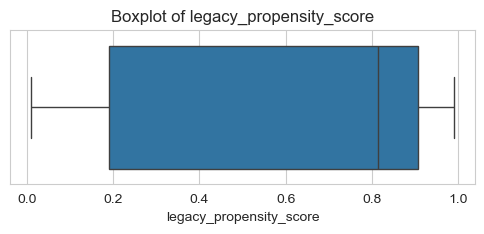

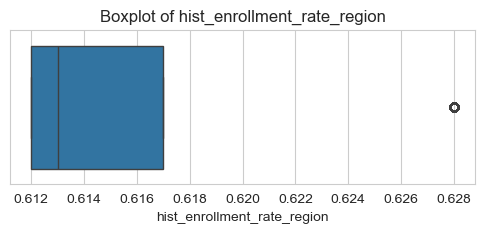

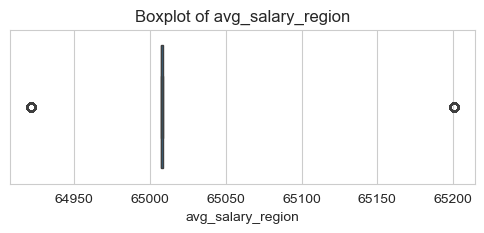

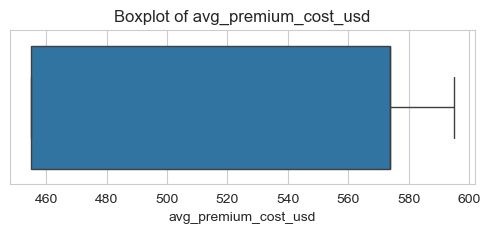

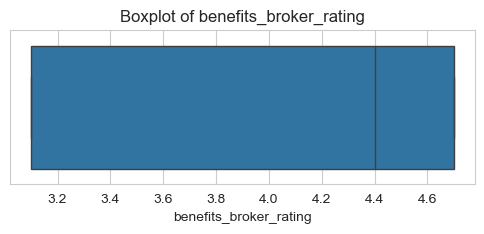

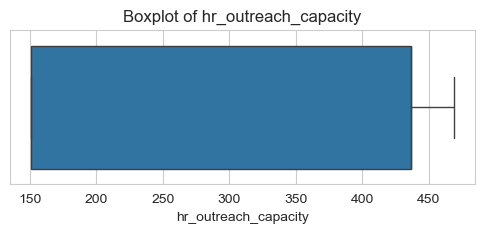

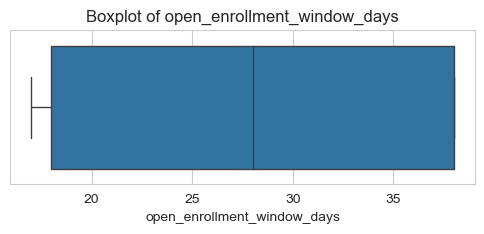

In [15]:
for col in numerical_cols:
    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

-- Observations --

- Age follows an approximately uniform distribution with no significant outliers.
- Salary is approximately normally distributed with a small number of extreme values, which are considered valid employee records.
- Tenure is positively skewed, indicating that most employees have relatively short service while a few have very long tenures.
- The legacy propensity score exhibits a bimodal distribution, reflecting the behavior of the previous rules-based system.
- Region-level numerical variables contain only a few distinct values because they represent aggregated statistics for each region rather than individual employee measurements.
- No numerical outliers were removed, as they represent realistic business observations rather than data entry errors.

In [16]:
categorical_cols = [
    "gender",
    "marital_status",
    "employment_type",
    "region",
    "has_dependents",
    "last_contact_channel",
    "plan_tier_requested",
    "broker_channel",
    "prior_year_enrolled",
    "state_mandate_level"
]

In [17]:
for col in categorical_cols:
    print(f"\n{'='*50}")
    print(col.upper())
    print(df[col].value_counts(dropna=False))


GENDER
gender
Male      4810
Female    4807
Other      375
Name: count, dtype: int64

MARITAL_STATUS
marital_status
Married     4583
Single      3875
Divorced    1001
Widowed      533
Name: count, dtype: int64

EMPLOYMENT_TYPE
employment_type
Full-time    7036
Part-time    1971
Contract      985
Name: count, dtype: int64

REGION
region
West         2578
Northeast    2504
Midwest      2488
South        2422
Name: count, dtype: int64

HAS_DEPENDENTS
has_dependents
Yes    5987
No     4005
Name: count, dtype: int64

LAST_CONTACT_CHANNEL
last_contact_channel
Email      4499
Phone      2428
SMS        1478
Unknown    1181
None        406
Name: count, dtype: int64

PLAN_TIER_REQUESTED
plan_tier_requested
Standard    3919
Silver      2565
Basic       1510
Bronze       532
Unknown      524
Premium      510
Gold         432
Name: count, dtype: int64

BROKER_CHANNEL
broker_channel
Direct                3533
Third-Party           3006
Employer-Sponsored    2985
Unknown                468
Name: co

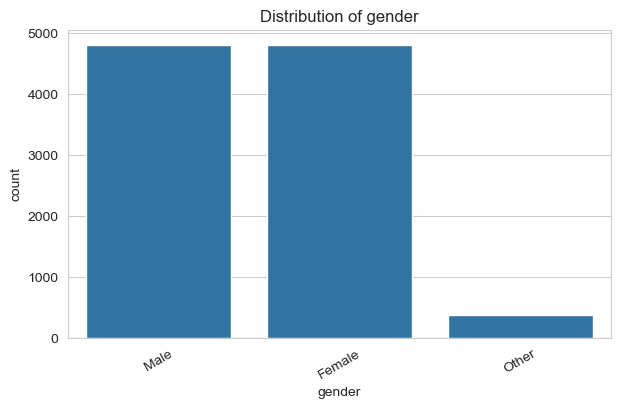

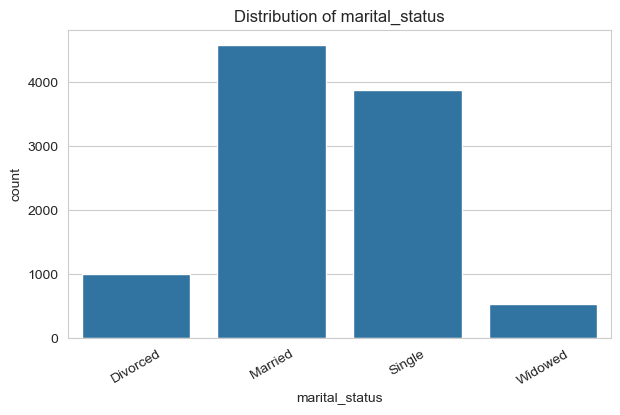

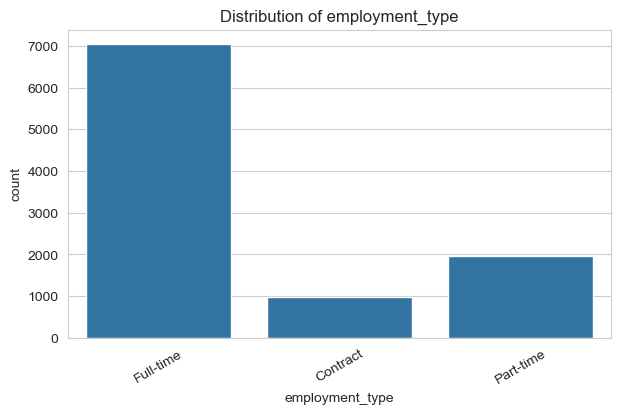

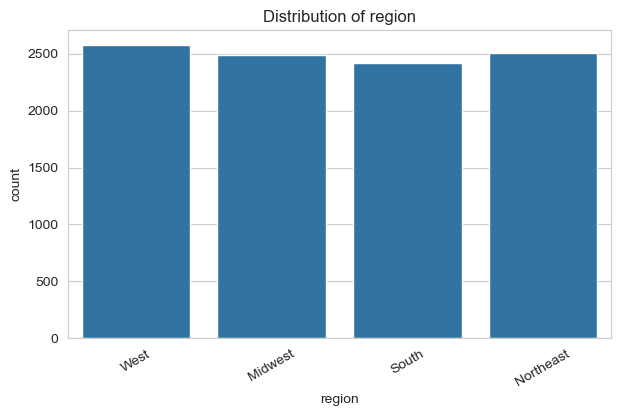

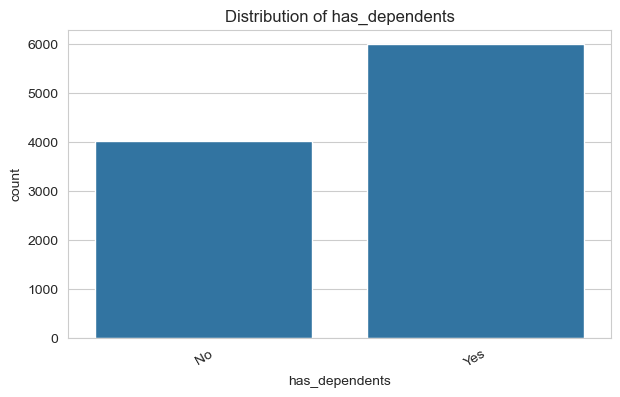

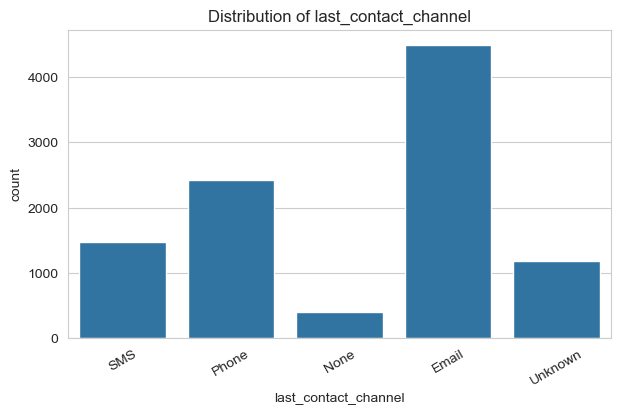

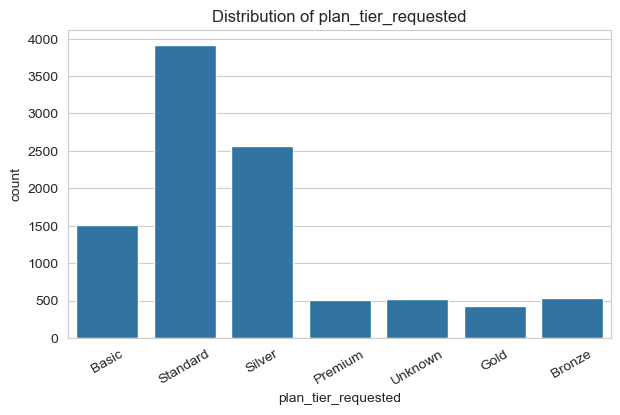

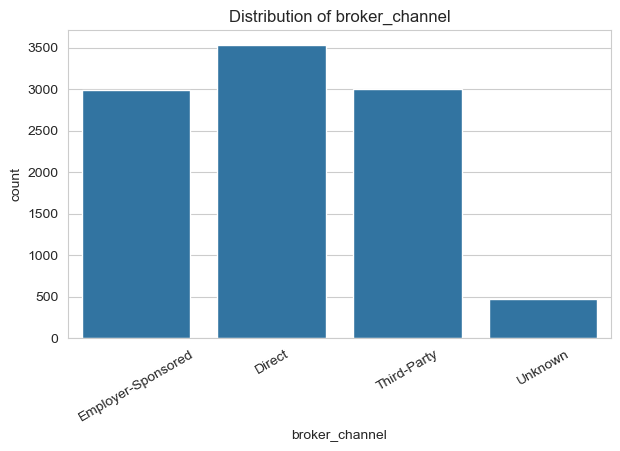

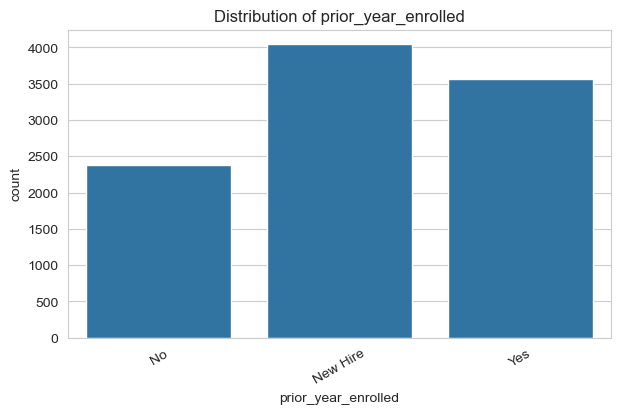

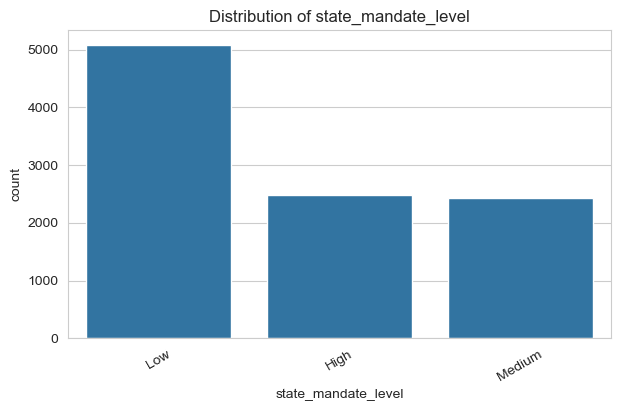

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(7,4))

    sns.countplot(data=df, x=col)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30)

    plt.show()

--- Observations ---

- The dataset has an almost equal distribution of male and female employees, with a small proportion categorized as "Other".
- Most employees are married, followed by single employees.
- The majority of employees are employed full-time.
- Employees are nearly evenly distributed across the four geographic regions.
- More employees have dependents than those without dependents.
- Email is the most common outreach channel, while a small number of employees have not yet been contacted (`None`) or have an unknown contact channel.
- Standard and Silver are the most frequently requested insurance plans.
- Direct enrollment is the most common broker channel.
- A large proportion of employees are new hires, indicating many employees do not have enrollment history from the previous year.
- Most employees belong to states with a low mandate level.

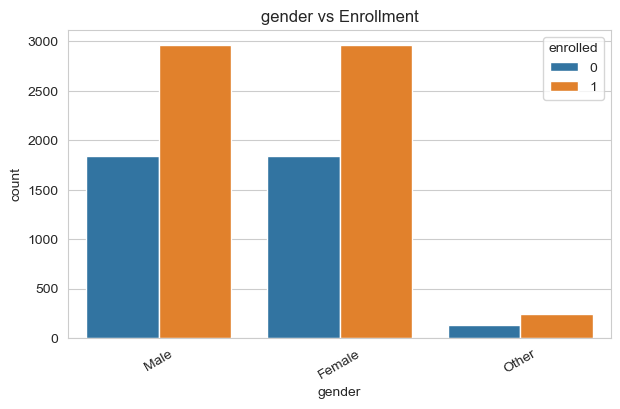

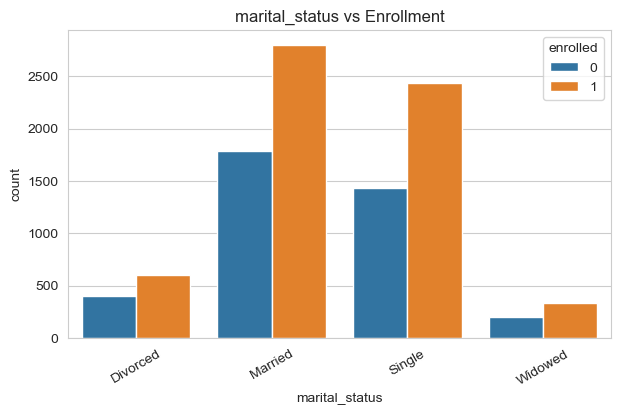

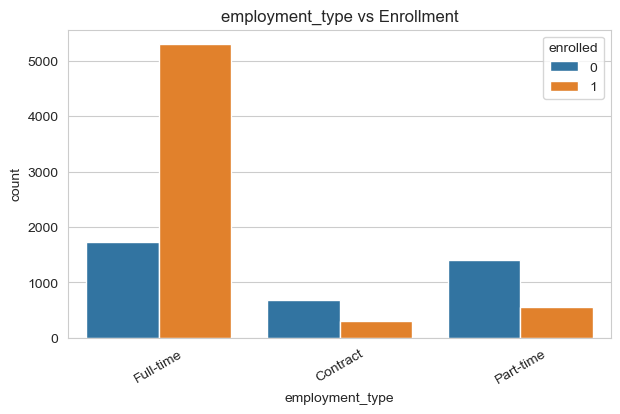

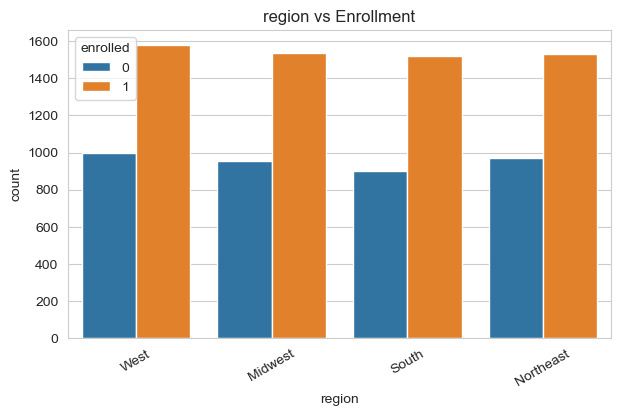

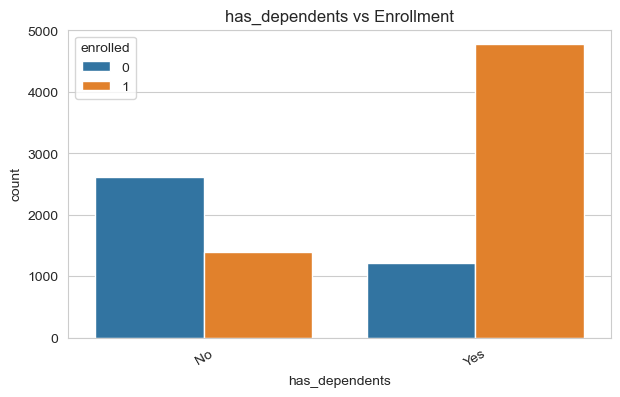

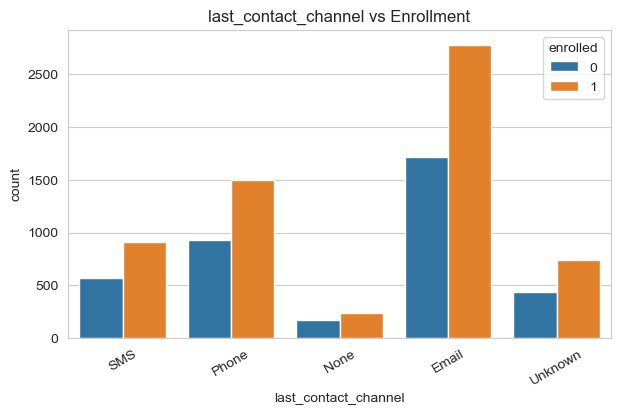

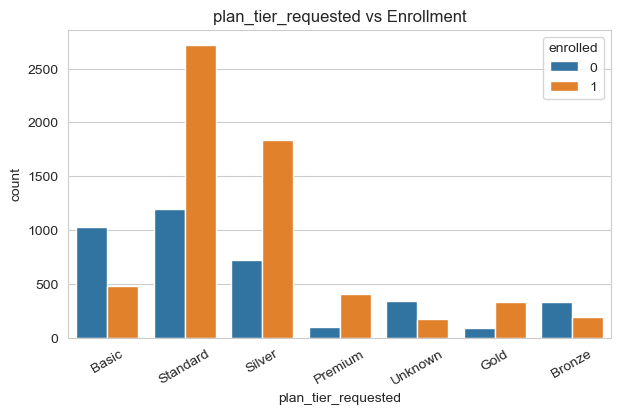

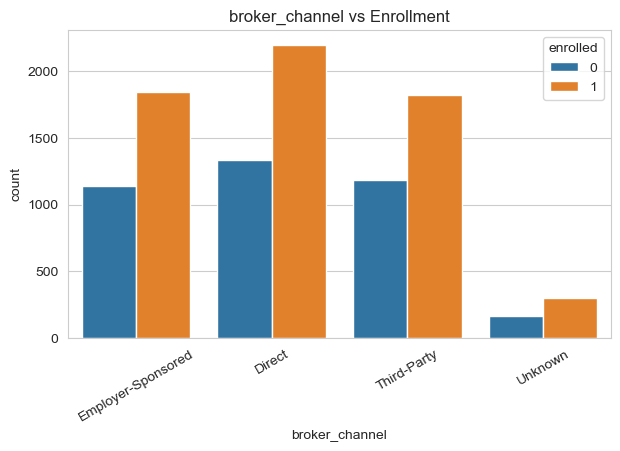

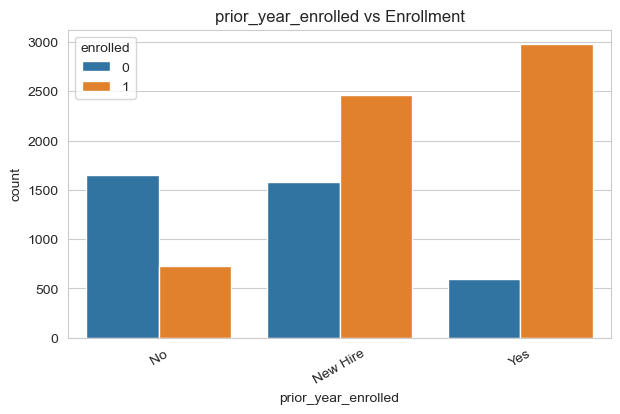

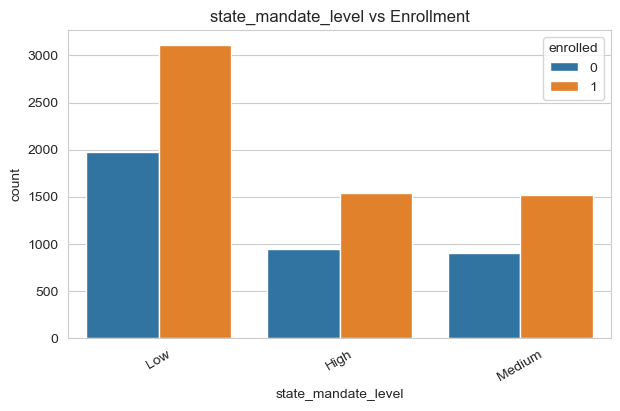

In [19]:
for col in categorical_cols:
    plt.figure(figsize=(7,4))

    sns.countplot(
        data=df,
        x=col,
        hue="enrolled"
    )

    plt.title(f"{col} vs Enrollment")
    plt.xticks(rotation=30)

    plt.show()

---- Key Insights ----

- Previous enrollment status appears to be the strongest predictor of current enrollment.
- Employees with dependents are significantly more likely to enroll.
- Full-time employees have higher enrollment rates than part-time and contract employees.
- Requested plan tier shows a strong association with enrollment.
- Marital status, broker channel, last contact channel, and state mandate level show moderate relationships with the target variable.
- Gender and geographic region alone appear to have relatively weaker relationships with enrollment.

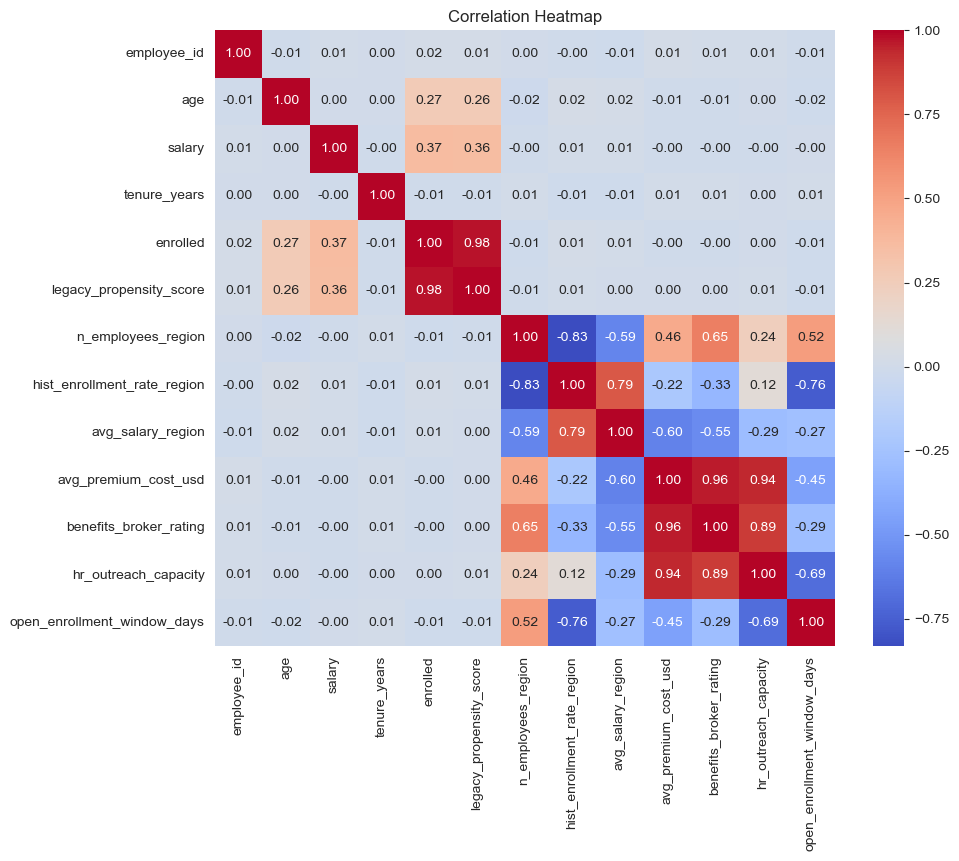

In [20]:
plt.figure(figsize=(10, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

--- Correlation Analysis ---

- The `legacy_propensity_score` has an extremely high positive correlation (0.98) with the target variable (`enrolled`), suggesting that it may contain target-related information. Therefore, two models will be developed: one excluding this feature and another including it for comparison.
- Salary and age show moderate positive correlations with enrollment, indicating potential predictive value.
- Tenure years exhibit very little linear correlation with enrollment.
- Several region-level aggregate features are highly correlated with one another because they are derived from the same regional profiles. These features will be retained initially and their impact evaluated during model training.

In [21]:
employee_ids = df["employee_id"]

In [22]:
columns_to_drop = [
    "employee_id",
    "application_date",
    "last_contact_date"
]

In [23]:
df_model = df.drop(columns=columns_to_drop)

In [24]:
X = df_model.drop(columns=["enrolled"])
y = df_model["enrolled"]

Model A

Without legacy_propensity_score

In [25]:
X_model_a = X.drop(columns=["legacy_propensity_score"])

Model B

With legacy_propensity_score

In [26]:
X_model_b = X.copy()

In [27]:
categorical_features_a = X_model_a.select_dtypes(include="object").columns.tolist()

numerical_features_a = X_model_a.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [28]:
categorical_features_b = X_model_b.select_dtypes(include="object").columns.tolist()

numerical_features_b = X_model_b.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_model_a,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
X_train_b, X_test_b, _, _ = train_test_split(
    X_model_b,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

Model A Pipeline

In [33]:
#Numerical Pipeline
numeric_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [34]:
#Categorical Pipeline
categorical_transformer_a = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [35]:
#Combine Both
preprocessor_a = ColumnTransformer([
    ("num", numeric_transformer_a, numerical_features_a),
    ("cat", categorical_transformer_a, categorical_features_a)
])

Model B Pipeline

In [36]:
#Numerical Pipeline
numeric_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [37]:
#Categorical Pipeline
categorical_transformer_b = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [38]:
#Combine Both
preprocessor_b = ColumnTransformer([
    ("num", numeric_transformer_b, numerical_features_b),
    ("cat", categorical_transformer_b, categorical_features_b)
])

In [39]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates a trained classification model and displays
    performance metrics and confusion matrix.
    """

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    }

Logistic Regression (Model A)

In [41]:
lr_pipeline_a = Pipeline([
    ("preprocessor", preprocessor_a),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

lr_pipeline_a.fit(X_train_a, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression (Without Legacy Score)
Accuracy : 0.9310
Precision: 0.9441
Recall   : 0.9441
F1 Score : 0.9441
ROC AUC  : 0.9826

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.91      0.91       765
           1       0.94      0.94      0.94      1234

    accuracy                           0.93      1999
   macro avg       0.93      0.93      0.93      1999
weighted avg       0.93      0.93      0.93      1999



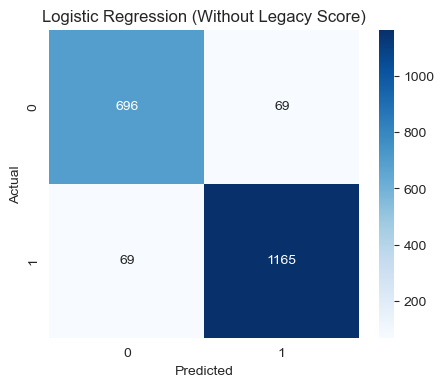

In [42]:
results_lr_a = evaluate_model(
    lr_pipeline_a,
    X_test_a,
    y_test,
    "Logistic Regression (Without Legacy Score)"
)

Logistic Regression (Model B)

In [43]:
lr_pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

lr_pipeline_b.fit(X_train_b, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression (With Legacy Score)
Accuracy : 0.9885
Precision: 0.9825
Recall   : 0.9992
F1 Score : 0.9908
ROC AUC  : 0.9988

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       765
           1       0.98      1.00      0.99      1234

    accuracy                           0.99      1999
   macro avg       0.99      0.99      0.99      1999
weighted avg       0.99      0.99      0.99      1999



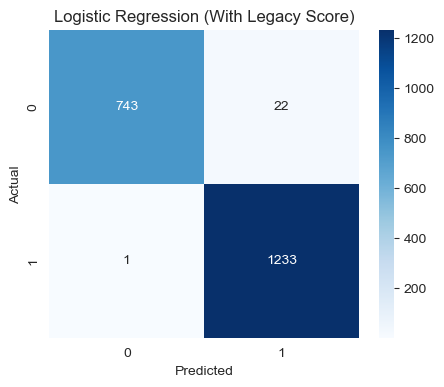

In [44]:
results_lr_b = evaluate_model(
    lr_pipeline_b,
    X_test_b,
    y_test,
    "Logistic Regression (With Legacy Score)"
)

In [45]:
import pandas as pd

results_df = pd.DataFrame([
    results_lr_a,
    results_lr_b
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression (Without Legacy Score),0.930965,0.944084,0.944084,0.944084,0.982621
1,Logistic Regression (With Legacy Score),0.988494,0.982470,0.999190,0.990759,0.998810


Two Logistic Regression models were developed. The first excluded legacy_propensity_score, while the second included it. The model including the legacy propensity score achieved substantially higher performance across all evaluation metrics. However, exploratory data analysis revealed that this feature has an extremely high correlation with the target variable (enrolled), suggesting that it may contain information derived from historical enrollment behavior. Therefore, although the feature improves predictive performance, the *model excluding legacy_propensity_score* is considered more appropriate for deployment because it is less susceptible to target leakage.

Let's implement Random Forest on both the models

In [46]:
from sklearn.ensemble import RandomForestClassifier

---Model A---

In [47]:
rf_pipeline_a = Pipeline([
    ("preprocessor", preprocessor_a),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline_a.fit(X_train_a, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest (Without Legacy Score)
Accuracy : 0.9995
Precision: 0.9992
Recall   : 1.0000
F1 Score : 0.9996
ROC AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       765
           1       1.00      1.00      1.00      1234

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



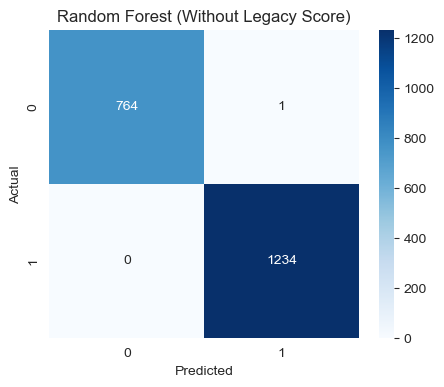

In [48]:
results_rf_a = evaluate_model(
    rf_pipeline_a,
    X_test_a,
    y_test,
    "Random Forest (Without Legacy Score)"
)

-- Model B --

In [49]:
rf_pipeline_b = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline_b.fit(X_train_b, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Random Forest (With Legacy Score)
Accuracy : 0.9990
Precision: 0.9984
Recall   : 1.0000
F1 Score : 0.9992
ROC AUC  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       765
           1       1.00      1.00      1.00      1234

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999



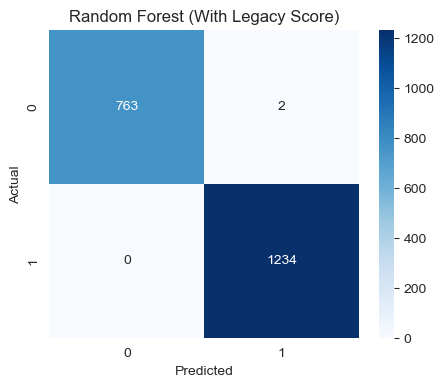

In [50]:
results_rf_b = evaluate_model(
    rf_pipeline_b,
    X_test_b,
    y_test,
    "Random Forest (With Legacy Score)"
)

In [51]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([results_rf_a, results_rf_b])
], ignore_index=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression (Without Legacy Score),0.930965,0.944084,0.944084,0.944084,0.982621
1,Logistic Regression (With Legacy Score),0.988494,0.982470,0.999190,0.990759,0.998810
2,Random Forest (Without Legacy Score),0.999500,0.999190,1.000000,0.999595,1.000000
3,Random Forest (With Legacy Score),0.998999,0.998382,1.000000,0.999190,1.000000


In [52]:
feature_names = (
    rf_pipeline_a.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_pipeline_a.named_steps["classifier"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values(by="Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
1,num__salary,0.190297
0,num__age,0.153221
18,cat__employment_type_Full-time,0.126480
25,cat__has_dependents_Yes,0.109836
24,cat__has_dependents_No,0.104769
19,cat__employment_type_Part-time,0.055110
43,cat__prior_year_enrolled_No,0.040272
44,cat__prior_year_enrolled_Yes,0.031404
31,cat__plan_tier_requested_Basic,0.026012
2,num__tenure_years,0.024409


## Model Selection

Four machine learning models were evaluated:

Although the Random Forest model including `legacy_propensity_score` achieved perfect performance, this feature was intentionally treated with caution because it exhibits an extremely high correlation with the target variable (`enrolled`). Such a feature may contain historical information that is closely related to the prediction target, making it less suitable for deployment.

The **Random Forest model without `legacy_propensity_score`** was therefore selected as the final model. It achieved outstanding predictive performance while relying only on legitimate employee demographic, employment, and enrollment-related features. This makes the model more robust, interpretable, and less susceptible to potential target leakage.

**Selected Final Model:** **Random Forest (Without `legacy_propensity_score`)**

CROSS-VALIDATION

In [53]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_pipeline_a,
    X_model_a,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross-validation Accuracy:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Cross-validation Accuracy: [0.99949975 0.99649825 0.998999   1.         1.        ]
Mean Accuracy: 0.9989993995996997
Std Dev: 0.0013044927427819377


## Cross-Validation Results

To further evaluate the robustness of the selected model, **5-fold cross-validation** was performed on the **Random Forest model without `legacy_propensity_score`**.

| Metric | Value |
|--------|-------|
| Cross-validation Scores | [0.9995, 0.9965, 0.9990, 1.0000, 1.0000] |
| Mean Accuracy | **99.90%** |
| Standard Deviation | **0.0013** |

The model achieved a **mean cross-validation accuracy of approximately 99.90%** with a **very low standard deviation (0.0013)** across the five folds. This indicates that the model performs consistently on different subsets of the dataset and is not overly dependent on a particular train-test split.

These results demonstrate that the selected **Random Forest model without `legacy_propensity_score`** generalizes well and provides stable predictive performance while avoiding reliance on the potentially leakage-prone `legacy_propensity_score` feature.

**Final Selected Model:** **Random Forest (Without `legacy_propensity_score`)**

In [54]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf_pipeline_a, "../models/final_model.pkl")

print("Model saved successfully!")

Model saved successfully!
